# Nikolov Compustat Hong Kong Cleaning

Build the annual Hong Kong Compustat panel for the Nikolov indirect-inference auxiliary policy functions.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / "outputs" / ".matplotlib"))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.v2.data.nikolov_compustat import (
    POLICY_VARIABLES,
    NikolovCompustatConfig,
    build_nikolov_policy_panel,
    load_compustat_hkg_raw,
)

RAW_DIR = ROOT / "data" / "raw"
PROCESSED_PATH = ROOT / "data" / "processed" / "nikolov_hkg_policy_panel.csv"
DIAGNOSTICS_PATH = ROOT / "outputs" / "data" / "nikolov_hkg_cleaning_summary.csv"
FIGURE_PATH = ROOT / "outputs" / "notebooks" / "11_nikolov_compustat_cleaning" / "nikolov_hkg_variable_distributions.png"

SAVE_OUTPUTS = True
SAVE_FIGURES = True
WINSOR_LIMITS = (0.01, 0.99)
MIN_OBSERVATIONS_PER_FIRM = 3

config = NikolovCompustatConfig(
    raw_dir=RAW_DIR,
    currency="HKD",
    excluded_gsectors=(40, 55),
    min_observations_per_firm=MIN_OBSERVATIONS_PER_FIRM,
    winsor_limits=WINSOR_LIMITS,
)

print(f"Raw directory: {RAW_DIR}")
print(f"Output panel: {PROCESSED_PATH}")

Raw directory: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/data/raw
Output panel: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/data/processed/nikolov_hkg_policy_panel.csv


/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Load And Clean

In [2]:
raw = load_compustat_hkg_raw(config)
panel, diagnostics = build_nikolov_policy_panel(config, raw=raw)

sample_counts = diagnostics.loc[
    diagnostics["section"].eq("sample"), ["metric", "rows", "firms"]
]

print("Sample counts")
print(sample_counts.to_string(index=False))
print()
print(
    f"Final panel: {len(panel):,} firm-years, "
    f"{panel['gvkey'].nunique():,} firms, "
    f"fiscal years {int(panel['fyearq'].min())}-{int(panel['fyearq'].max())}"
)

Sample counts
                   metric  rows  firms
                      raw 21706    312
                   fqtr_4  5942    311
                  fic_hkg  5942    311
                 currency  4866    242
               industrial  2561    131
             consolidated  2561    131
          standard_format  2561    131
exclude_financial_utility  2339    122
          positive_assets  2334    122
           positive_ppent  2333    122
   finite_capx_oibdp_cash  2205    122
 finite_current_variables  2205    122
     with_future_leverage  2083    119
    min_firm_observations  2080    116

Final panel: 2,080 firm-years, 116 firms, fiscal years 1999-2024


## Diagnostics

In [3]:
missing = diagnostics.loc[diagnostics["section"].eq("source_missing_rate"), ["metric", "value"]].copy()
missing["missing_pct"] = 100.0 * missing["value"]

imputation = diagnostics.loc[diagnostics["section"].eq("imputation_rate"), ["metric", "value"]].copy()
imputation["imputed_pct"] = 100.0 * imputation["value"]

balance = panel.groupby("gvkey").size()

print("Missing rates after baseline filters")
print(missing[["metric", "missing_pct"]].round(2).to_string(index=False))
print()
print("Zero-imputation rates in final panel")
print(imputation[["metric", "imputed_pct"]].round(2).to_string(index=False))
print()
print(
    "Panel balance: "
    f"mean={balance.mean():.1f}, median={balance.median():.1f}, "
    f"min={balance.min()}, max={balance.max()} annual observations per firm"
)

Missing rates after baseline filters
 metric  missing_pct
    atq         0.00
 ppentq         0.00
  capxy         4.93
 oibdpy         0.56
  dlttq        24.82
   dlcq        12.43
   cheq         0.00
   dvty        45.56
prstkcy        87.91

Zero-imputation rates in final panel
 metric  imputed_pct
  dlttq        24.47
   dlcq        11.88
   dvty        45.10
prstkcy        86.73

Panel balance: mean=17.9, median=20.0, min=3, max=25 annual observations per firm


In [4]:
summary = panel[list(POLICY_VARIABLES)].describe(percentiles=[0.01, 0.5, 0.99]).T
summary = summary[["count", "mean", "std", "min", "1%", "50%", "99%", "max"]]

print("Policy-function variables")
print(summary.round(4).to_string())
print()
print("Auxiliary-regression x columns: log_k, profitability, leverage")
print("Auxiliary-regression y columns: investment_rate, future_leverage, payout_rate")
print("Market-to-book is omitted because this extract lacks usable market value and shares-outstanding fields.")

Policy-function variables
                  count    mean     std    min      1%     50%      99%      max
investment_rate  2080.0  0.0333  0.0448  0.000  0.0000  0.0169   0.2532   0.2563
future_leverage  2080.0  0.1962  0.2065  0.000  0.0000  0.1389   1.0974   1.1373
payout_rate      2080.0  0.0147  0.0243  0.000  0.0000  0.0032   0.1248   0.1249
log_k            2080.0  6.2582  2.4628  0.000  0.0520  6.2534  11.8503  11.8736
profitability    2080.0  0.0386  0.1051 -0.447 -0.4375  0.0398   0.3160   0.3160
leverage         2080.0  0.1945  0.2038  0.000  0.0000  0.1410   1.0904   1.1373

Auxiliary-regression x columns: log_k, profitability, leverage
Auxiliary-regression y columns: investment_rate, future_leverage, payout_rate
Market-to-book is omitted because this extract lacks usable market value and shares-outstanding fields.


## Variable Distributions

Saved figure: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/11_nikolov_compustat_cleaning/nikolov_hkg_variable_distributions.png


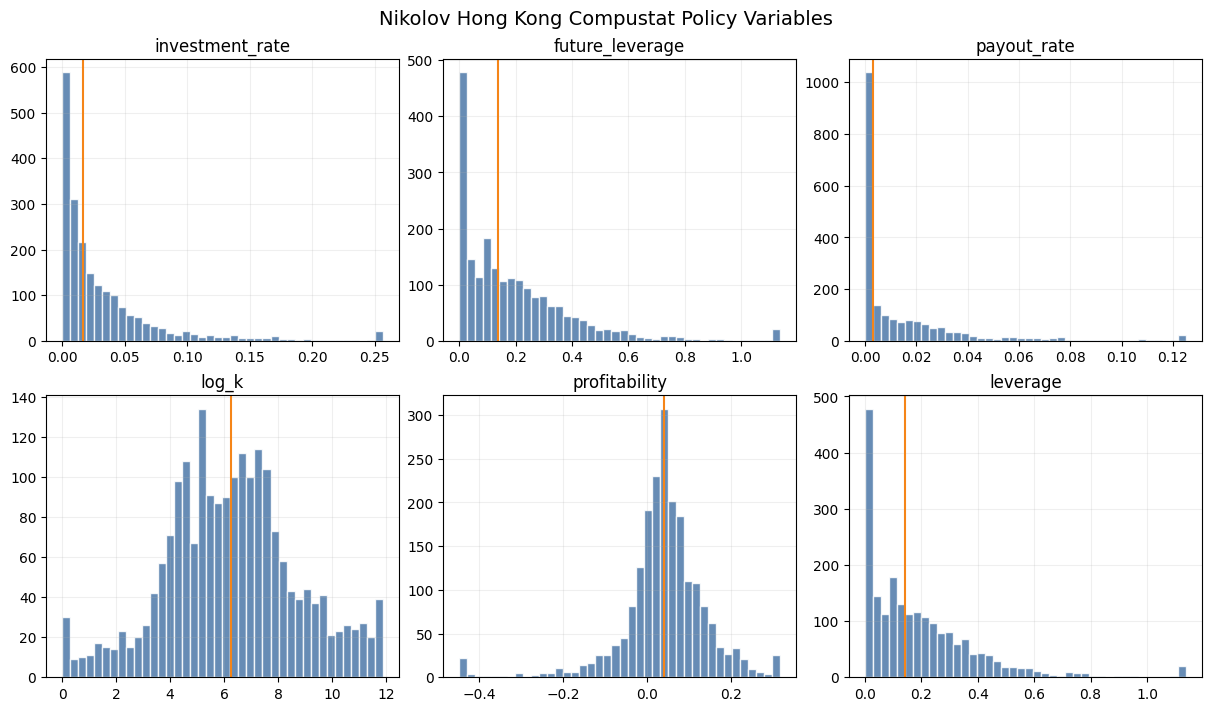

In [5]:
plot_columns = [
    "investment_rate",
    "future_leverage",
    "payout_rate",
    "log_k",
    "profitability",
    "leverage",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
for ax, column in zip(axes.ravel(), plot_columns):
    ax.hist(panel[column], bins=40, color="#4C78A8", alpha=0.85, edgecolor="white")
    ax.axvline(panel[column].median(), color="#F58518", linewidth=1.5)
    ax.set_title(column)
    ax.grid(alpha=0.2)

fig.suptitle("Nikolov Hong Kong Compustat Policy Variables", fontsize=14)

if SAVE_FIGURES:
    FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_PATH, dpi=160)
    print(f"Saved figure: {FIGURE_PATH}")

plt.show()

## Save Clean Panel

In [6]:
if SAVE_OUTPUTS:
    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    DIAGNOSTICS_PATH.parent.mkdir(parents=True, exist_ok=True)
    panel.to_csv(PROCESSED_PATH, index=False)
    diagnostics.to_csv(DIAGNOSTICS_PATH, index=False)
    print(f"Saved cleaned panel: {PROCESSED_PATH}")
    print(f"Saved diagnostics: {DIAGNOSTICS_PATH}")
else:
    print("SAVE_OUTPUTS is False; no files written.")

Saved cleaned panel: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/data/processed/nikolov_hkg_policy_panel.csv
Saved diagnostics: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/data/nikolov_hkg_cleaning_summary.csv
